/opt/homebrew/Caskroom/miniconda/base/envs/dwarfhunt/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


z=0.50  mags=['-27.395', '-28.649', '-27.889']  colors=['1.254', '-0.760', '0.494']
z=0.61  mags=['-27.318', '-27.685', '-27.747']  colors=['0.366', '0.062', '0.428']
z=0.71  mags=['-27.911', '-27.582', '-28.231']  colors=['-0.329', '0.649', '0.319']
z=0.82  mags=['-27.079', '-28.269', '-29.317']  colors=['1.190', '1.048', '2.238']
z=0.93  mags=['-27.005', '-27.401', '-29.622']  colors=['0.396', '2.221', '2.617']
z=1.04  mags=['-26.947', '-27.316', '-30.115']  colors=['0.369', '2.799', '3.168']
z=1.14  mags=['-26.887', '-27.259', '-29.313']  colors=['0.372', '2.054', '2.426']
z=1.25  mags=['-26.782', '-27.209', '-28.931']  colors=['0.427', '1.722', '2.149']
z=1.36  mags=['-26.685', '-27.128', '-28.932']  colors=['0.443', '1.804', '2.247']
z=1.46  mags=['-26.671', '-27.025', '-29.666']  colors=['0.354', '2.641', '2.995']
z=1.57  mags=['-26.687', '-26.960', '-29.089']  colors=['0.273', '2.129', '2.402']
z=1.68  mags=['-26.700', '-26.974', '-28.728']  colors=['0.274', '1.754', '2.028']
z=

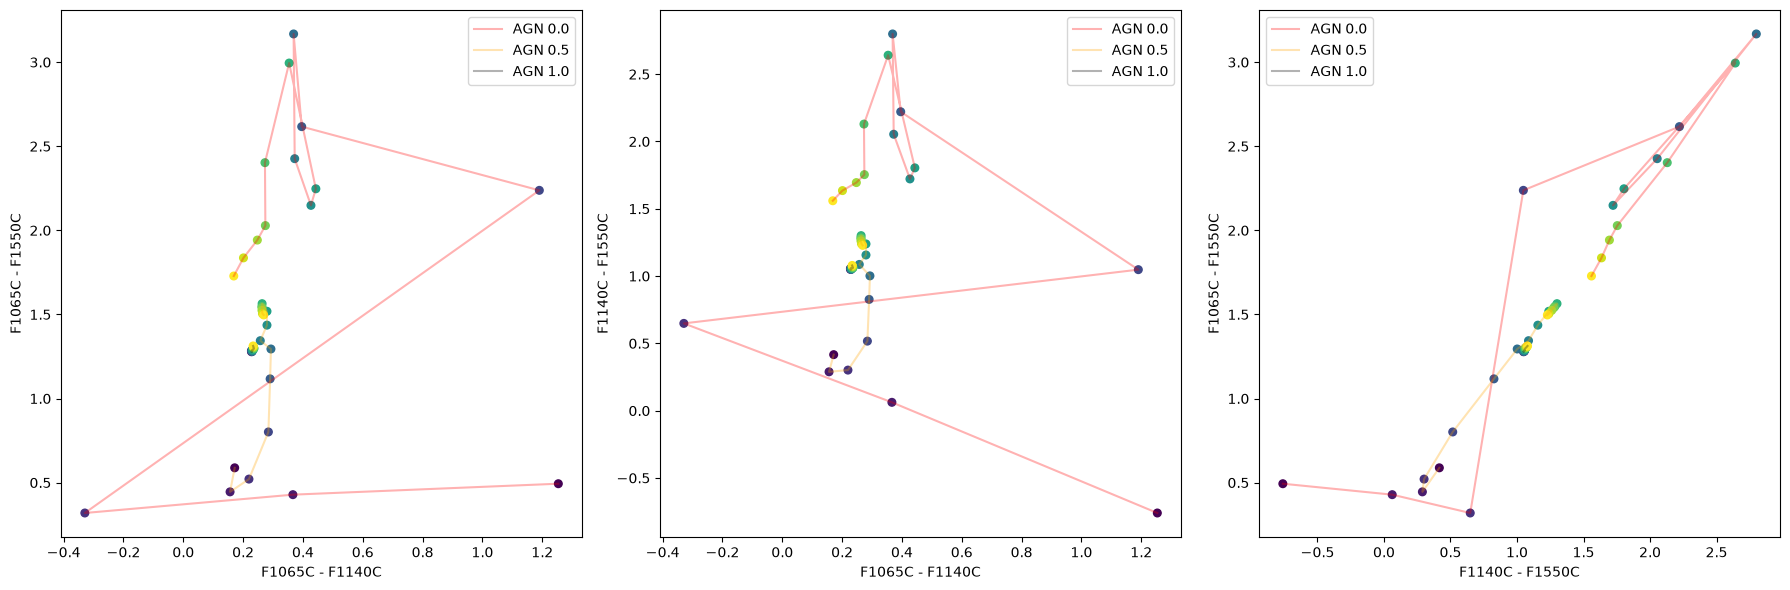

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from species.read.read_filter import ReadFilter
from species.phot.syn_phot import SyntheticPhotometry

def load_swire_data(file):
    """
    Load the SWIRE data from a text file, based on https://www.iasf-milano.inaf.it/~polletta/templates/swire_templates.html

    The templates should be in the format of a text file with the following columns:
    1. Wavelength (in Angstroms)
    2. Flux (normalized at 5500 Angstroms in erg / cm^2 / s / Angstrom)

    Returns ( wavelengths in microns, fluxes in erg / cm^2 / s / Angstrom )
    """
    file = np.loadtxt(file, comments='#', usecols=(0, 1))
    wavelengths = file[:, 0] * 1e-4  
    fluxes = file[:, 1]
    return wavelengths, fluxes

def redshift_data(wavelengths, fluxes, z):
    """
    Redshift the data by a given redshift z.

    Parameters:
    - wavelengths: array of wavelengths in microns
    - fluxes: array of fluxes in erg / cm^2 / s / Angstrom
    - z: redshift value

    Returns:
    - redshifted_wavelengths: array of redshifted wavelengths in microns
    - redshifted_fluxes: array of redshifted fluxes in erg / cm^2 / s / Angstrom
    """
    redshifted_wavelengths = wavelengths * (1 + z)
    redshifted_fluxes = fluxes
    return redshifted_wavelengths, redshifted_fluxes

def synth_mags(wavelength, flux, filter_names):
    """
    Calculate synthetic magnitudes for a given filter.
    """
    mag_list = []
    for filter in filter_names:
        filters_data = SyntheticPhotometry(filter).spectrum_to_magnitude(wavelength, flux)
        mag_list.append(filters_data[0])
    return mag_list

def get_full_redshift_mag_loop(file):
    data = load_swire_data(file)
    redshift_values = np.linspace(0.5, 2, 15)
    full_mag_data = []
    for z in redshift_values:
        red_data = redshift_data(data[0], data[1], z)
        mag_data = synth_mags(red_data[0], red_data[1], ["JWST/MIRI.F1065C", "JWST/MIRI.F1140C", "JWST/MIRI.F1550C"])
        # get the first element of each tuple in the list of tuples
        un_tupled_data = [item[0] for item in mag_data]
        color_color = get_color_color_data(un_tupled_data)
        full_mag_data.append((z, un_tupled_data, color_color))
    return full_mag_data

def get_color_color_data(mag_array): 
    """
    Calculate color-color data from an array of magnitudes.

    Parameters:
    - mag_array: array of magnitudes in the order [F1065C, F1140C, F1550C]

    Returns:
    - color_color_data: array of color-color data in the order [F1065C-F1140C, F1140C-F1550C]
    """
    color_color_data = [
        mag_array[0] - mag_array[1], # F1065C - F1140C
        mag_array[1] - mag_array[2], # F1140C - F1550C
        mag_array[0] - mag_array[2]] # F1065C - F1550C
    return color_color_data

def plot_color_color(data, title, ax, color, x_idx, y_idx, x_label, y_label):
    z_values = [item[0] for item in data]
    color_color_data = [item[2] for item in data]
    x = [item[x_idx] for item in color_color_data]
    y = [item[y_idx] for item in color_color_data]
    sc = ax.scatter(x, y, c=z_values, cmap='viridis', s=30)
    ax.plot(x, y, color=color, alpha=0.3, label=title)
    ax.set_xlabel(x_label); ax.set_ylabel(y_label); ax.legend()

ngc6090_data = get_full_redshift_mag_loop('./galaxy-data/swire-library/N6090_template_norm.sed') #AGN 0.0
for z, mags, colors in ngc6090_data:
    print(f"z={z:.2f}  mags={[f'{m:.3f}' for m in mags]}  colors={[f'{c:.3f}' for c in colors]}")

mrk231_data = get_full_redshift_mag_loop('./galaxy-data/swire-library/Mrk231_template_norm.sed') #AGN 0.5
QSO1_data = get_full_redshift_mag_loop('./galaxy-data/swire-library/QSO1_template_norm.sed') #AGN 1.0
print(QSO1_data)
# Build three sub color-color graphs. First graph: 1065 - 1140(x) vs 1065 - 1550(y). Second graph 1065 - 1140 (x) vs 1140 - 1550(y). Third graph: 1065 - 1550 (y) vs 1140 - 1550 (x)
fig, ax = plt.subplots(1, 3, figsize=(18, 6))
plot_color_color(ngc6090_data, 'AGN 0.0', ax[0], 'red', 0, 2, 'F1065C - F1140C', 'F1065C - F1550C')
plot_color_color(mrk231_data, 'AGN 0.5', ax[0], 'orange', 0, 2, 'F1065C - F1140C', 'F1065C - F1550C')
plot_color_color(QSO1_data, 'AGN 1.0', ax[0], 'black', 0, 2, 'F1065C - F1140C', 'F1065C - F1550C')
plot_color_color(ngc6090_data, 'AGN 0.0', ax[1], 'red', 0, 1, 'F1065C - F1140C', 'F1140C - F1550C')
plot_color_color(mrk231_data, 'AGN 0.5', ax[1], 'orange', 0, 1, 'F1065C - F1140C', 'F1140C - F1550C')
plot_color_color(QSO1_data, 'AGN 1.0', ax[1], 'black', 0, 1, 'F1065C - F1140C', 'F1140C - F1550C')
plot_color_color(ngc6090_data, 'AGN 0.0', ax[2], 'red', 1, 2, 'F1140C - F1550C', 'F1065C - F1550C')
plot_color_color(mrk231_data, 'AGN 0.5', ax[2], 'orange', 1, 2, 'F1140C - F1550C', 'F1065C - F1550C')
plot_color_color(QSO1_data, 'AGN 1.0', ax[2], 'black', 1, 2, 'F1140C - F1550C', 'F1065C - F1550C')

plt.tight_layout()





# data = load_swire_data('./galaxy-data/swire-library/Mrk231_template_norm.sed')
# #red_data = redshift_data(data[0], data[1], 1.0)  # Example redshift of 1.0
# mag_data = synth_mags(data[0], data[1], ["JWST/MIRI.F1065C", "JWST/MIRI.F1140C", "JWST/MIRI.F1550C"])
# print(mag_data)
# fig, ax = plt.subplots()
# ax.plot(data[0], data[1], label='Original SWIRE Data', color='blue')
# ax.scatter([10.65], [0], label='JWST/MIRI.F1065C', color='orange')
# ax.scatter([11.40], [0], label='JWST/MIRI.F1140C', color='green')
# ax.scatter([15.50], [0], label='JWST/MIRI.F1550C', color='red')
# # #ax.plot(red_data[0], red_data[1] * red_data[0], label='Redshifted Data (z=1.0)', color='red', linestyle='--')
# ax.set_xlabel('Wavelength (microns)')
# # ax.set_ylabel('Flux (vFv) (erg / cm^2 / s)')
# ax.set_xscale('log')
# ax.set_yscale('log')
# print(data)
    